In [60]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
 
# CONFIG, SUBSET = "v/35", "hand-crafted"
# CONFIG, SUBSET = "v/35", "algorithm-generated"
# CONFIG, SUBSET = "v/24", "algorithm-generated"
# CONFIG, SUBSET = "v/24", "hand-crafted"
# CONFIG, SUBSET = "k/21", "hand-crafted"
# CONFIG, SUBSET = "k/21", "algorithm-generated"
# CONFIG, SUBSET = "k/34", "hand-crafted"
CONFIG, SUBSET = "k/34", "algorithm-generated"

SCORE_DIR = Path(f"outputs/sal/scores/qwen3-8b/{SUBSET}/{CONFIG}")
 
trajectories = []
for fp in sorted(SCORE_DIR.glob("*.json"), key=lambda p: int(p.stem)):
    with open(fp) as f:
        trajectories.append(json.load(f))
 
print(f"Loaded {len(trajectories)} trajectories from {SCORE_DIR}")
 
# Discover all score variant names from the first file
score_names = sorted(trajectories[0]["steps"][0]["scores"].keys())
print(f"Score variants ({len(score_names)}): {score_names}")

Loaded 126 trajectories from outputs/sal/scores/qwen3-8b/algorithm-generated/k/34
Score variants (14): ['gradnorm_l1_centered', 'gradnorm_l1_uncentered', 'gradnorm_l2_centered', 'gradnorm_l2_uncentered', 'sal_noref_c1', 'sal_noref_c2', 'sal_noref_c3', 'sal_noref_c4', 'sal_noref_c5', 'sal_wref_c1', 'sal_wref_c2', 'sal_wref_c3', 'sal_wref_c4', 'sal_wref_c5']


In [61]:
def normalize_agent(role: str) -> str:
    """Collapse Orchestrator variants to 'Orchestrator'."""
    if "orchestrator" in role.lower():
        return "Orchestrator"
    return role
 
 
def evaluate_all(
    trajectories: list[dict],
    score_names: list[str],
) -> dict[str, dict]:
    """Compute step_acc and agent_acc for every variant × {asc, desc}.
 
    Returns
    -------
    dict[variant_name] → {
        "desc_step_acc", "desc_agent_acc",
        "asc_step_acc",  "asc_agent_acc",
        "total"
    }
    """
    results = {}
 
    for variant in score_names:
        desc_step = 0
        desc_agent = 0
        asc_step = 0
        asc_agent = 0
        total = 0
 
        for traj in trajectories:
            steps = traj["steps"]
            if not steps:
                continue
            total += 1
 
            meta = traj["metadata"]
            gt_step = int(meta["mistake_step"])
            gt_agent = meta["mistake_agent"]
 
            # Descending: highest score = predicted mistake
            best_desc = max(steps, key=lambda s: s["scores"][variant])
            pred_step_desc = best_desc["step_idx"]
            pred_agent_desc = normalize_agent(best_desc["role"])
 
            if pred_step_desc == gt_step:
                desc_step += 1
            if gt_agent.lower() in pred_agent_desc.lower():
                desc_agent += 1
 
            # Ascending: lowest score = predicted mistake
            best_asc = min(steps, key=lambda s: s["scores"][variant])
            pred_step_asc = best_asc["step_idx"]
            pred_agent_asc = normalize_agent(best_asc["role"])
 
            if pred_step_asc == gt_step:
                asc_step += 1
            if gt_agent.lower() in pred_agent_asc.lower():
                asc_agent += 1
 
        results[variant] = {
            "desc_step_acc":  desc_step / total,
            "desc_agent_acc": desc_agent / total,
            "asc_step_acc":   asc_step / total,
            "asc_agent_acc":  asc_agent / total,
            "total":          total,
        }
 
    return results

In [62]:
eval_results = evaluate_all(trajectories, score_names)
 
# ── Print table ──────────────────────────────────────────────────
header = (f"{'variant':<28s} | {'↓ desc (higher=mistake)':<36s} | "
          f"{'↑ asc (lower=mistake)':<36s}")
sub    = (f"{'':28s} | {'step_acc':>10s} {'agent_acc':>10s} {'best':>6s} | "
          f"{'step_acc':>10s} {'agent_acc':>10s} {'best':>6s}")
 
print("=" * 100)
print(header)
print(sub)
print("-" * 100)
 
for variant in score_names:
    r = eval_results[variant]
    # Mark which direction is better for step_acc
    desc_better = "◄" if r["desc_step_acc"] >= r["asc_step_acc"] else ""
    asc_better  = "◄" if r["asc_step_acc"] > r["desc_step_acc"] else ""
 
    print(f"{variant:<28s} | "
          f"{r['desc_step_acc']:>10.4f} {r['desc_agent_acc']:>10.4f} {desc_better:>6s} | "
          f"{r['asc_step_acc']:>10.4f} {r['asc_agent_acc']:>10.4f} {asc_better:>6s}")
 
print("=" * 100)

variant                      | ↓ desc (higher=mistake)              | ↑ asc (lower=mistake)               
                             |   step_acc  agent_acc   best |   step_acc  agent_acc   best
----------------------------------------------------------------------------------------------------
gradnorm_l1_centered         |     0.0238     0.2381        |     0.1825     0.3571      ◄
gradnorm_l1_uncentered       |     0.0079     0.2222        |     0.2222     0.5079      ◄
gradnorm_l2_centered         |     0.0238     0.2143        |     0.1349     0.3413      ◄
gradnorm_l2_uncentered       |     0.0238     0.2222        |     0.2381     0.5079      ◄
sal_noref_c1                 |     0.0238     0.2143        |     0.2540     0.5397      ◄
sal_noref_c2                 |     0.0159     0.1984        |     0.2143     0.4921      ◄
sal_noref_c3                 |     0.0238     0.2063        |     0.2222     0.5000      ◄
sal_noref_c4                 |     0.0238     0.2063        |   

In [63]:
import pandas as pd

rows = []
for variant in score_names:
    r = eval_results[variant]
    rows.append({
        "variant": variant,
        "desc_step_acc":  round(r["desc_step_acc"], 4),
        "desc_agent_acc": round(r["desc_agent_acc"], 4),
        "asc_step_acc":   round(r["asc_step_acc"], 4),
        "asc_agent_acc":  round(r["asc_agent_acc"], 4),
    })

df = pd.DataFrame(rows)
df.to_csv('z_tmp.tsv', sep='\t', index=False)
print(df.to_string(index=False))

               variant  desc_step_acc  desc_agent_acc  asc_step_acc  asc_agent_acc
  gradnorm_l1_centered         0.0238          0.2381        0.1825         0.3571
gradnorm_l1_uncentered         0.0079          0.2222        0.2222         0.5079
  gradnorm_l2_centered         0.0238          0.2143        0.1349         0.3413
gradnorm_l2_uncentered         0.0238          0.2222        0.2381         0.5079
          sal_noref_c1         0.0238          0.2143        0.2540         0.5397
          sal_noref_c2         0.0159          0.1984        0.2143         0.4921
          sal_noref_c3         0.0238          0.2063        0.2222         0.5000
          sal_noref_c4         0.0238          0.2063        0.2222         0.5159
          sal_noref_c5         0.0238          0.2063        0.2302         0.5159
           sal_wref_c1         0.0397          0.2540        0.0952         0.2540
           sal_wref_c2         0.0238          0.2381        0.0794         0.2937
    

In [64]:
def extract_scores_and_labels(
    trajectories: list[dict],
    variant: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract mistake/normal scores.
 
    Returns: (mistake_scores, normal_scores, all_scores)
    """
    mistake_scores = []
    normal_scores = []
 
    for traj in trajectories:
        for step in traj["steps"]:
            sc = step["scores"][variant]
            if step["is_mistake"]:
                mistake_scores.append(sc)
            else:
                normal_scores.append(sc)
 
    m, n = np.array(mistake_scores), np.array(normal_scores)
    return m, n, np.concatenate([n, m])
 
 
def extract_strip_data(
    trajectories: list[dict],
    variant: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract raw (traj_idx, score, is_mistake) per step for strip plot.
 
    Returns: (traj_indices, scores, is_mistake) — all (N_total_steps,)
    """
    traj_indices = []
    scores = []
    is_mistake = []
 
    for i, traj in enumerate(trajectories):
        traj_idx = i + 1  # 1-based
        for step in traj["steps"]:
            traj_indices.append(traj_idx)
            scores.append(step["scores"][variant])
            is_mistake.append(step["is_mistake"])
 
    return np.array(traj_indices), np.array(scores), np.array(is_mistake, dtype=bool)
 
 
def extract_percentile_data(
    trajectories: list[dict],
    variant: str,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Compute per-step percentile rank within each trajectory.
 
    Percentile rank: 0% = lowest score in trajectory, 100% = highest.
 
    Returns: (traj_indices, percentiles, is_mistake) — all (N_total_steps,)
    """
    traj_indices = []
    percentiles = []
    is_mistake_arr = []
 
    for i, traj in enumerate(trajectories):
        traj_idx = i + 1
        steps = traj["steps"]
        scores = np.array([s["scores"][variant] for s in steps])
        n = len(scores)
 
        # Percentile: rank position normalized to 0–100
        ranks_asc = scores.argsort().argsort()  # 0 = lowest, n-1 = highest
        pctiles = ranks_asc / max(n - 1, 1) * 100.0
 
        for j, step in enumerate(steps):
            traj_indices.append(traj_idx)
            percentiles.append(pctiles[j])
            is_mistake_arr.append(step["is_mistake"])
 
    return (
        np.array(traj_indices),
        np.array(percentiles),
        np.array(is_mistake_arr, dtype=bool),
    )
 
# %% [markdown]
# ## Cell 6: 3-panel plot function
 
# %%
C_NORMAL       = "steelblue"
C_NORMAL_EDGE  = "#3a6d8c"
C_MISTAKE      = "#d62728"
C_MISTAKE_DARK = "#8b0000"
 
 
def plot_variant(
    trajectories: list[dict],
    variant: str,
    n_bins: int = 50,
):
    """3-panel plot for one scoring variant.
 
    [Left]   Dual-axis histogram (normal left y-axis, mistake right y-axis)
    [Middle] Per-trajectory raw score strip plot
    [Right]  Per-trajectory percentile rank strip plot (0–100%)
    """
    mistake_sc, normal_sc, all_sc = extract_scores_and_labels(trajectories, variant)
    strip_traj, strip_scores, strip_mask = extract_strip_data(trajectories, variant)
    pct_traj, pctiles, pct_mask = extract_percentile_data(trajectories, variant)
 
    fig, axes = plt.subplots(1, 3, figsize=(21, 5),
                             gridspec_kw={"width_ratios": [1, 1, 1]})
 
    # ── Left: Dual-axis histogram ───────────────────────────────────
    ax_l = axes[0]
    lo = min(all_sc.min(), 0)
    hi = np.percentile(all_sc, 99.5)
    bins = np.linspace(lo, hi, n_bins)
 
    ax_l.hist(
        normal_sc, bins=bins, alpha=0.4, color=C_NORMAL,
        edgecolor=C_NORMAL_EDGE, linewidth=0.7,
        label=f"Normal (n={len(normal_sc)})",
    )
    ax_l.set_xlabel("Score")
    ax_l.set_ylabel("Count (normal)", color=C_NORMAL)
    ax_l.tick_params(axis="y", labelcolor=C_NORMAL)
 
    ax_r = ax_l.twinx()
    ax_r.hist(
        mistake_sc, bins=bins, alpha=0.4, color=C_MISTAKE,
        edgecolor=C_MISTAKE_DARK, linewidth=0.9,
        label=f"Mistake (n={len(mistake_sc)})",
    )
    ax_r.set_ylabel("Count (mistake)", color=C_MISTAKE)
    ax_r.tick_params(axis="y", labelcolor=C_MISTAKE)
 
    # Combined legend
    h1, l1 = ax_l.get_legend_handles_labels()
    h2, l2 = ax_r.get_legend_handles_labels()
    ax_l.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9)
    ax_l.set_title(f"Score distribution — {variant}")
 
    # ── Middle: Raw score strip plot ────────────────────────────────
    ax = axes[1]
    ax.scatter(
        strip_traj[~strip_mask], strip_scores[~strip_mask],
        c=C_NORMAL, s=12, alpha=0.25, label="Normal", rasterized=True,
    )
    ax.scatter(
        strip_traj[strip_mask], strip_scores[strip_mask],
        c=C_MISTAKE, s=30, alpha=1.0, edgecolors=C_MISTAKE_DARK,
        linewidths=0.6, label="Mistake", zorder=5,
    )
    ax.set_xlabel("Trajectory index")
    ax.set_ylabel("Score")
    ax.set_title(f"Per-step raw scores — {variant}")
    ax.legend(loc="upper right", fontsize=9)
 
    # ── Right: Percentile rank strip plot ───────────────────────────
    ax = axes[2]
    ax.scatter(
        pct_traj[~pct_mask], pctiles[~pct_mask],
        c=C_NORMAL, s=12, alpha=0.25, label="Normal", rasterized=True,
    )
    ax.scatter(
        pct_traj[pct_mask], pctiles[pct_mask],
        c=C_MISTAKE, s=30, alpha=1.0, edgecolors=C_MISTAKE_DARK,
        linewidths=0.6, label="Mistake", zorder=5,
    )
    ax.set_xlabel("Trajectory index")
    ax.set_ylabel("Percentile rank (%)")
    ax.set_ylim(-2, 102)
    ax.axhline(100, color="grey", ls="--", lw=0.5, alpha=0.5)
    ax.axhline(50,  color="grey", ls=":",  lw=0.5, alpha=0.4)
    ax.set_title("Percentile rank (100% = highest in traj)")
    ax.legend(loc="lower right", fontsize=9)
 
    fig.tight_layout()
    plt.show()

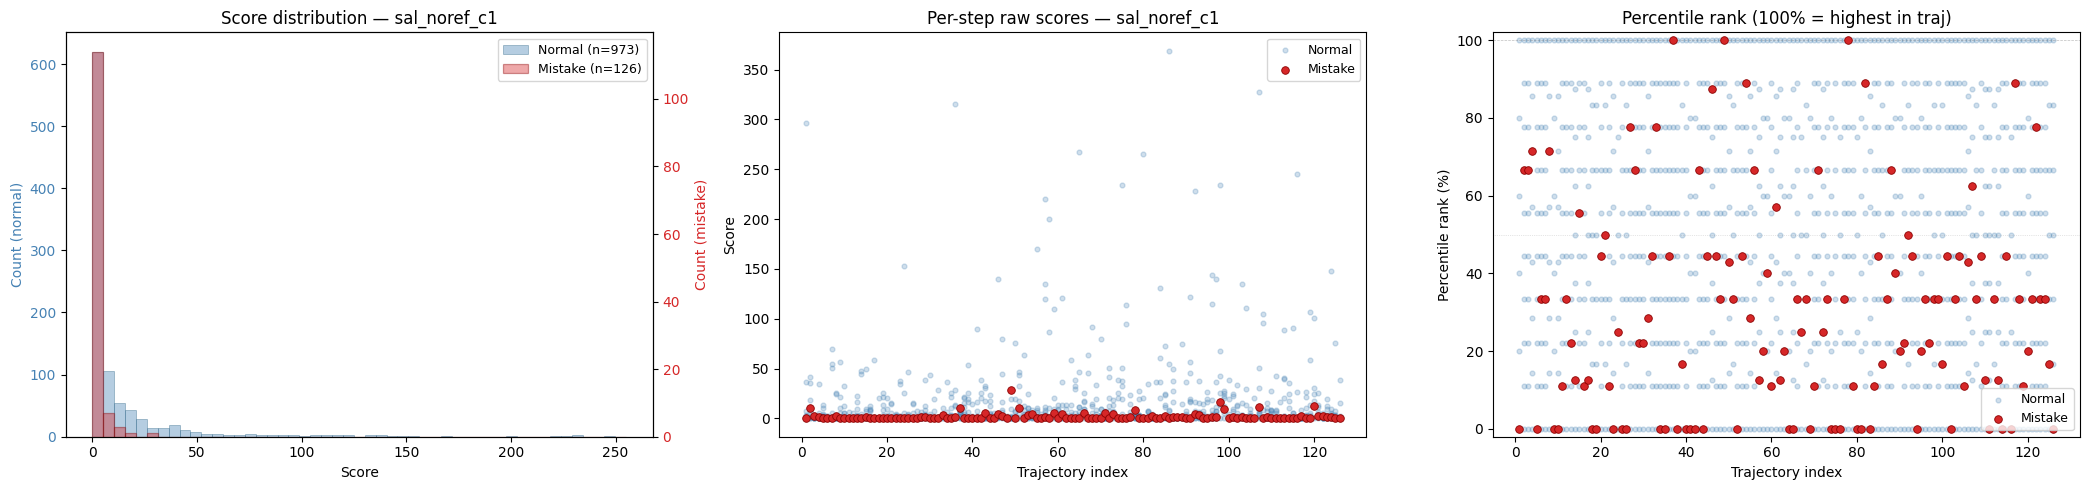

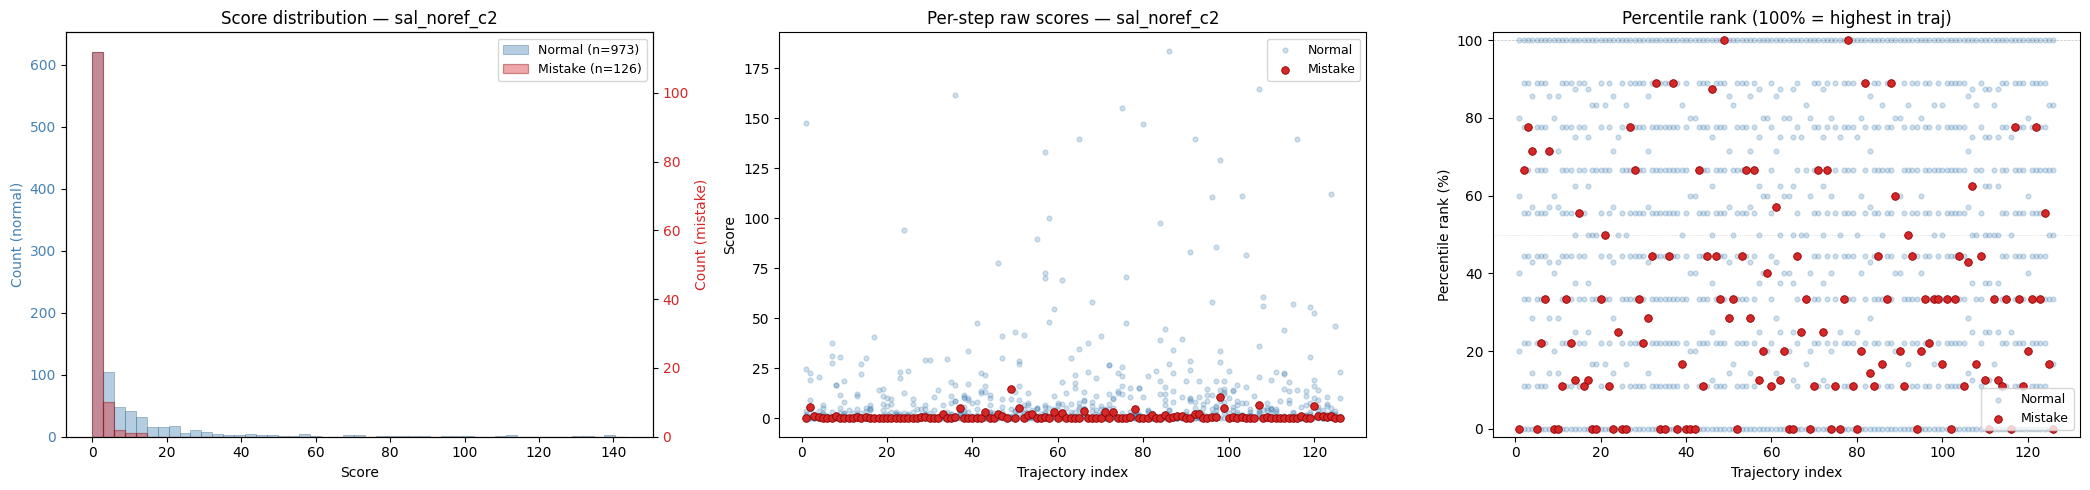

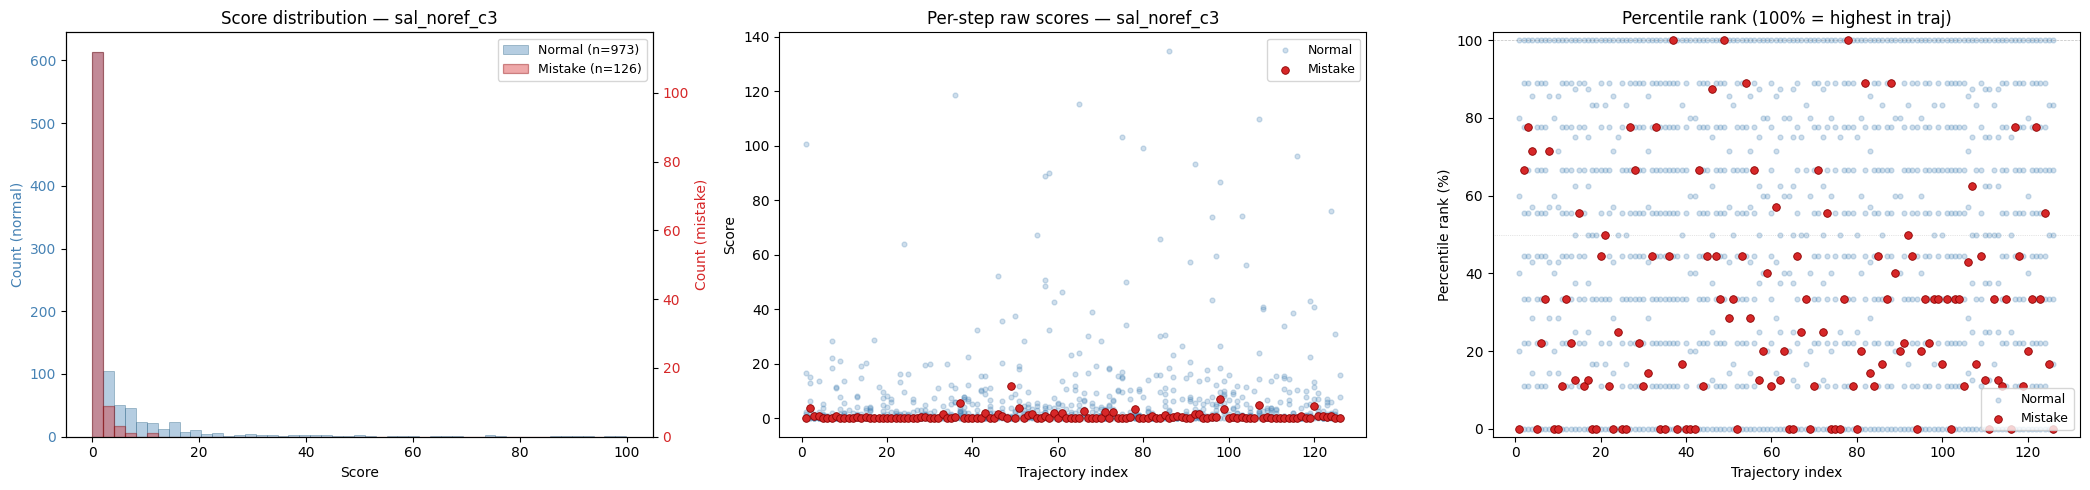

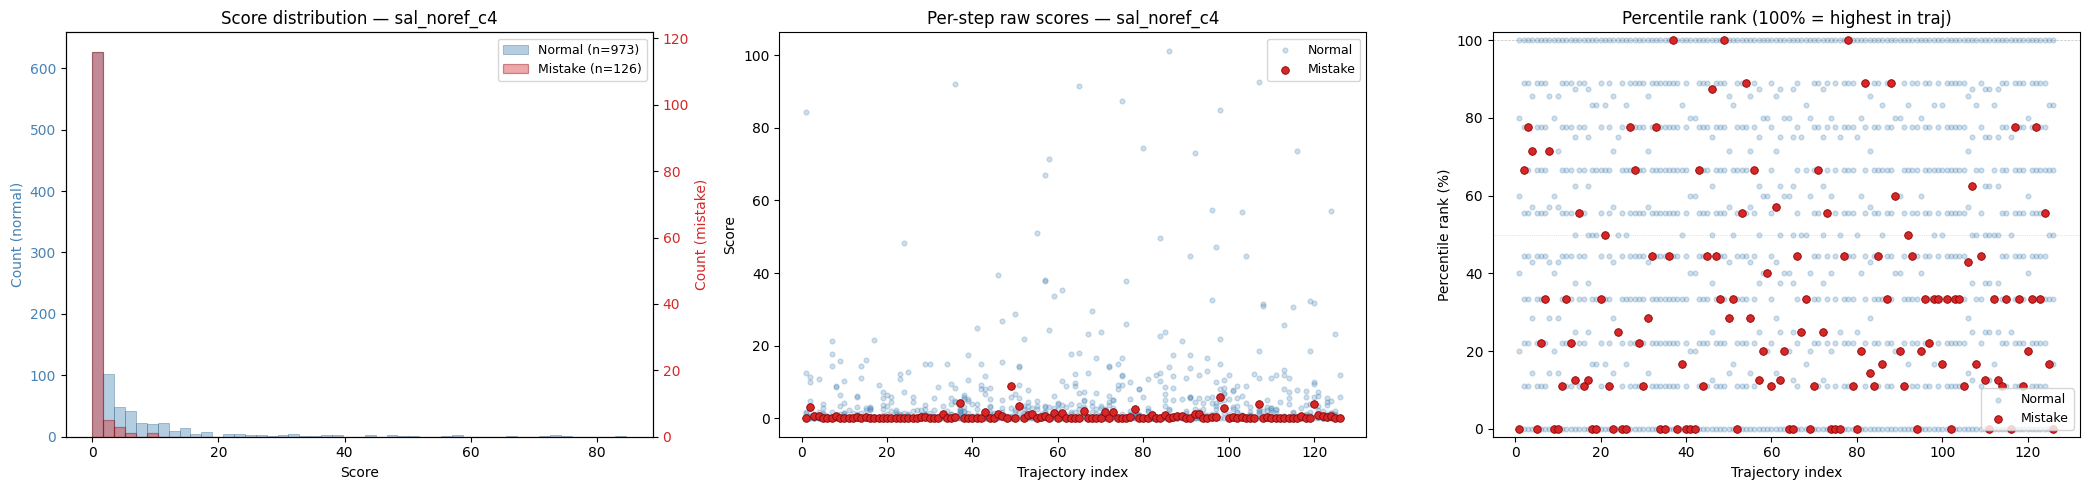

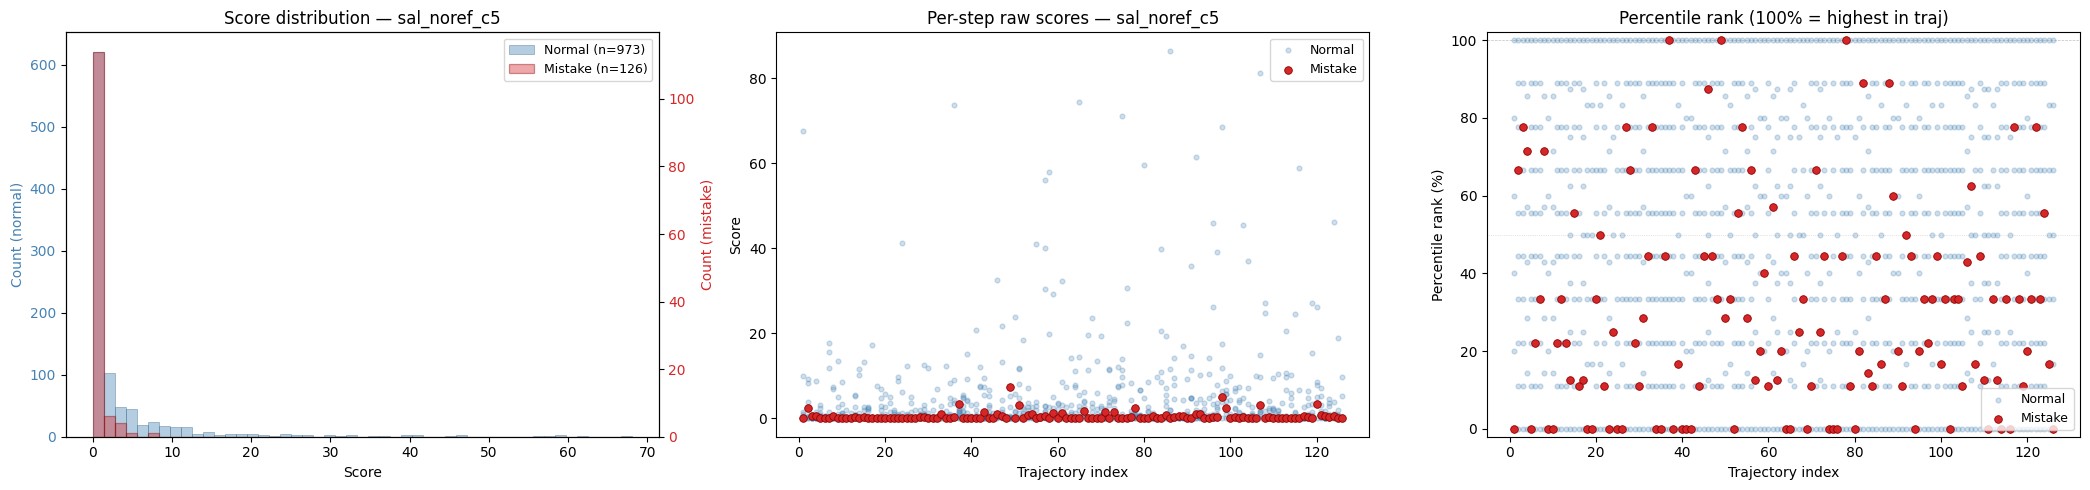

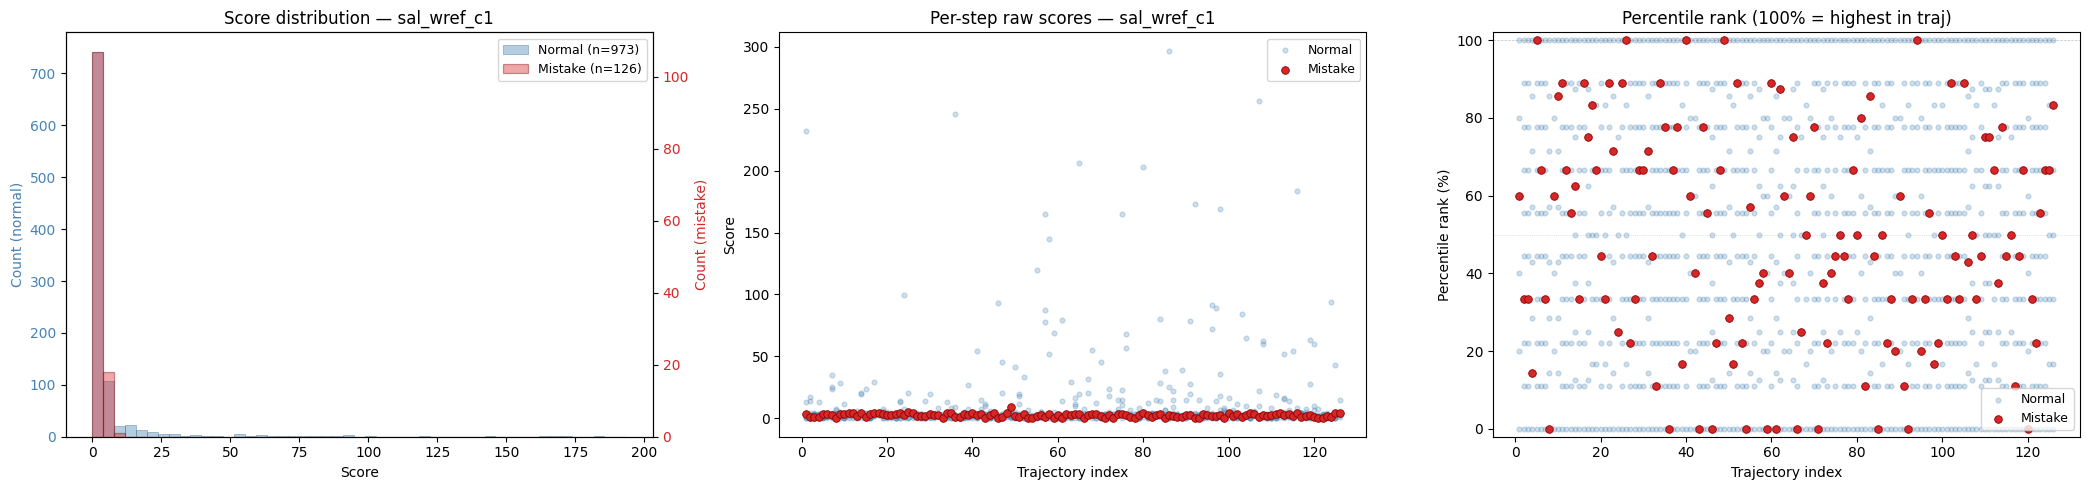

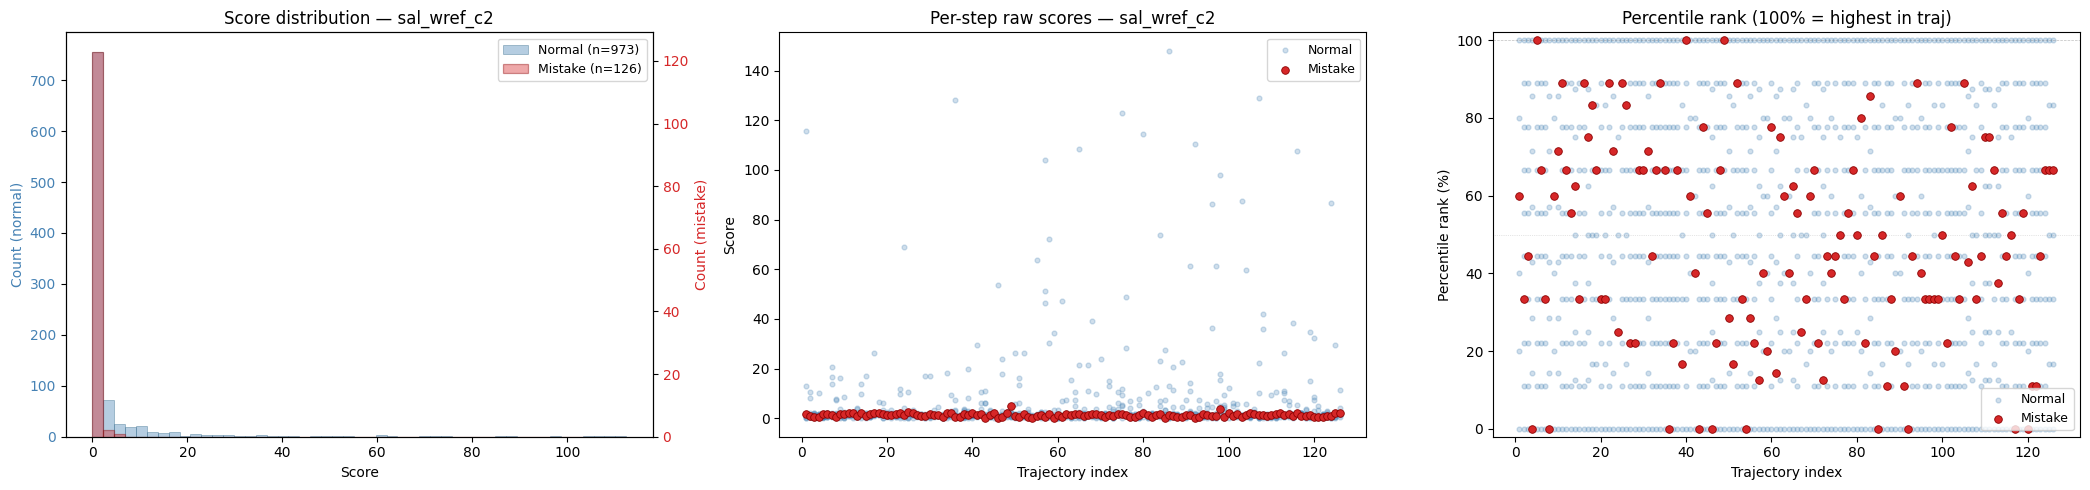

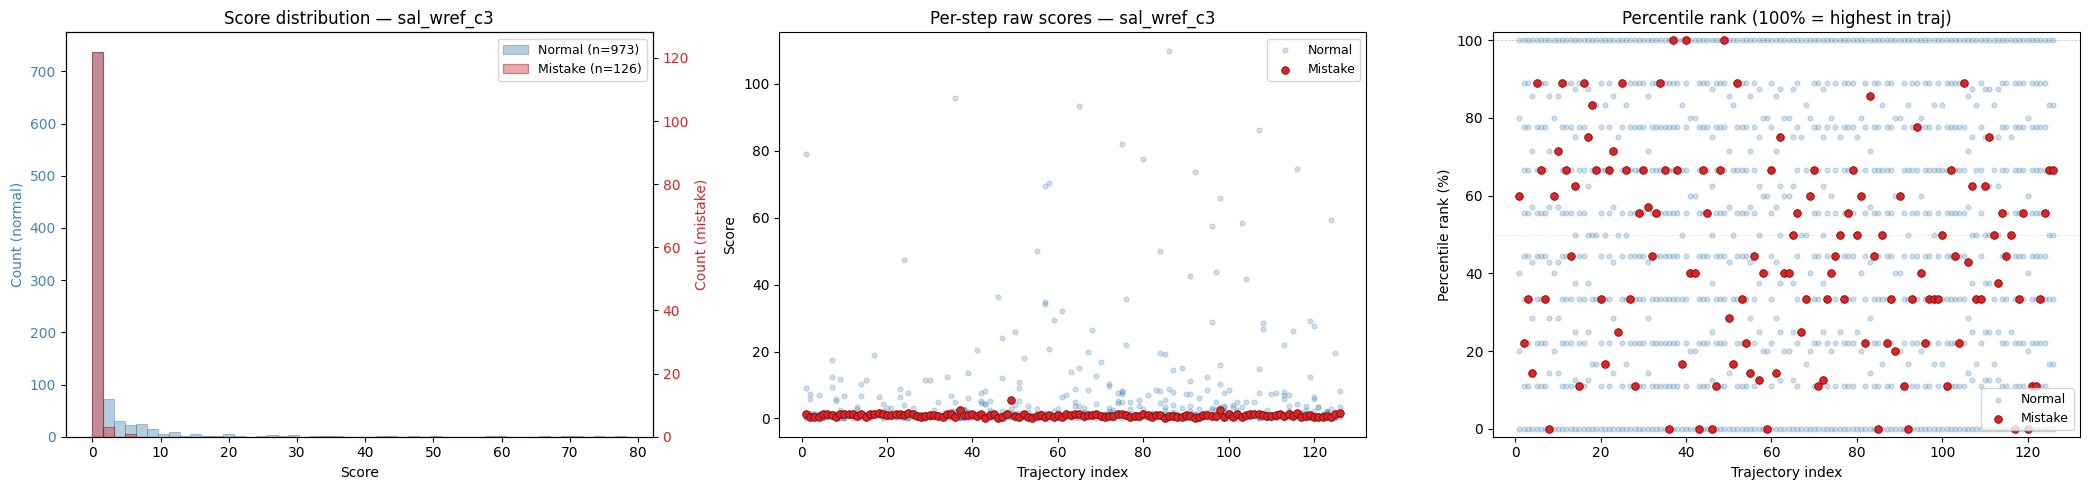

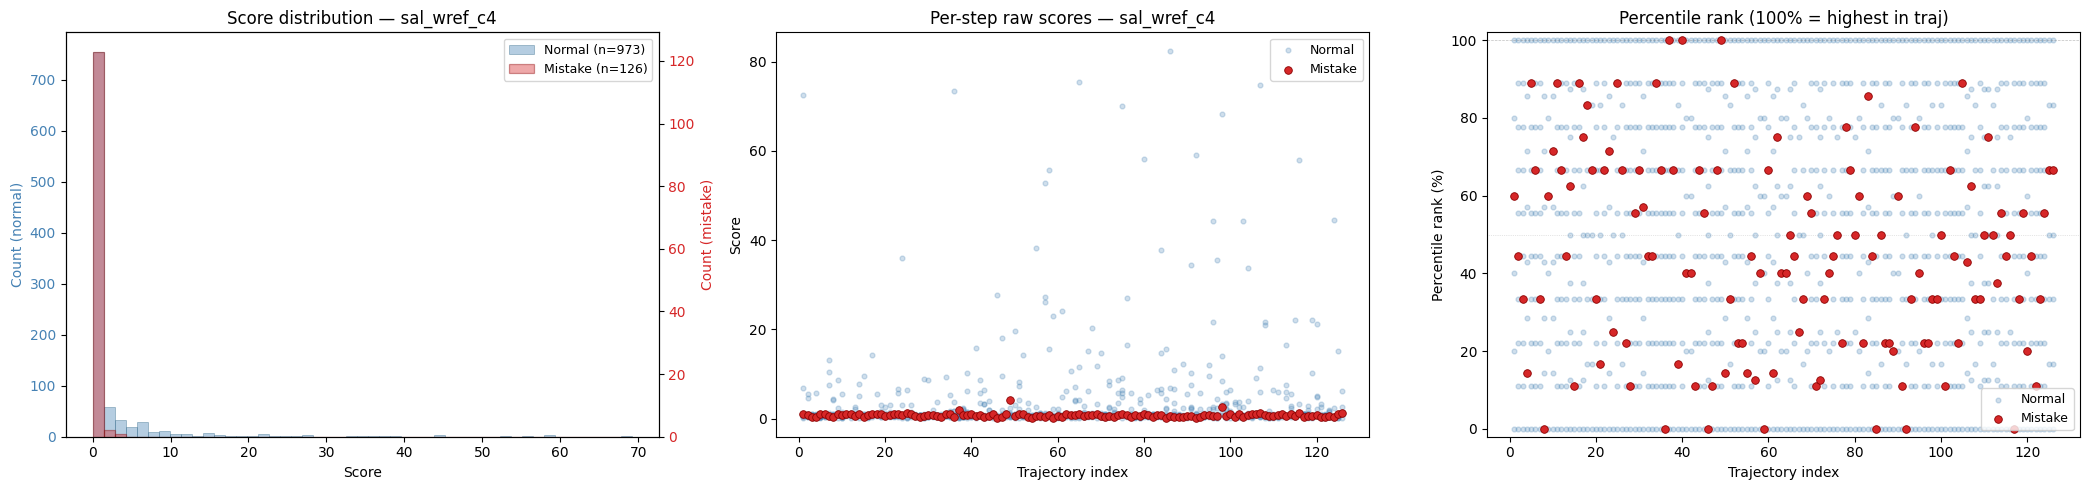

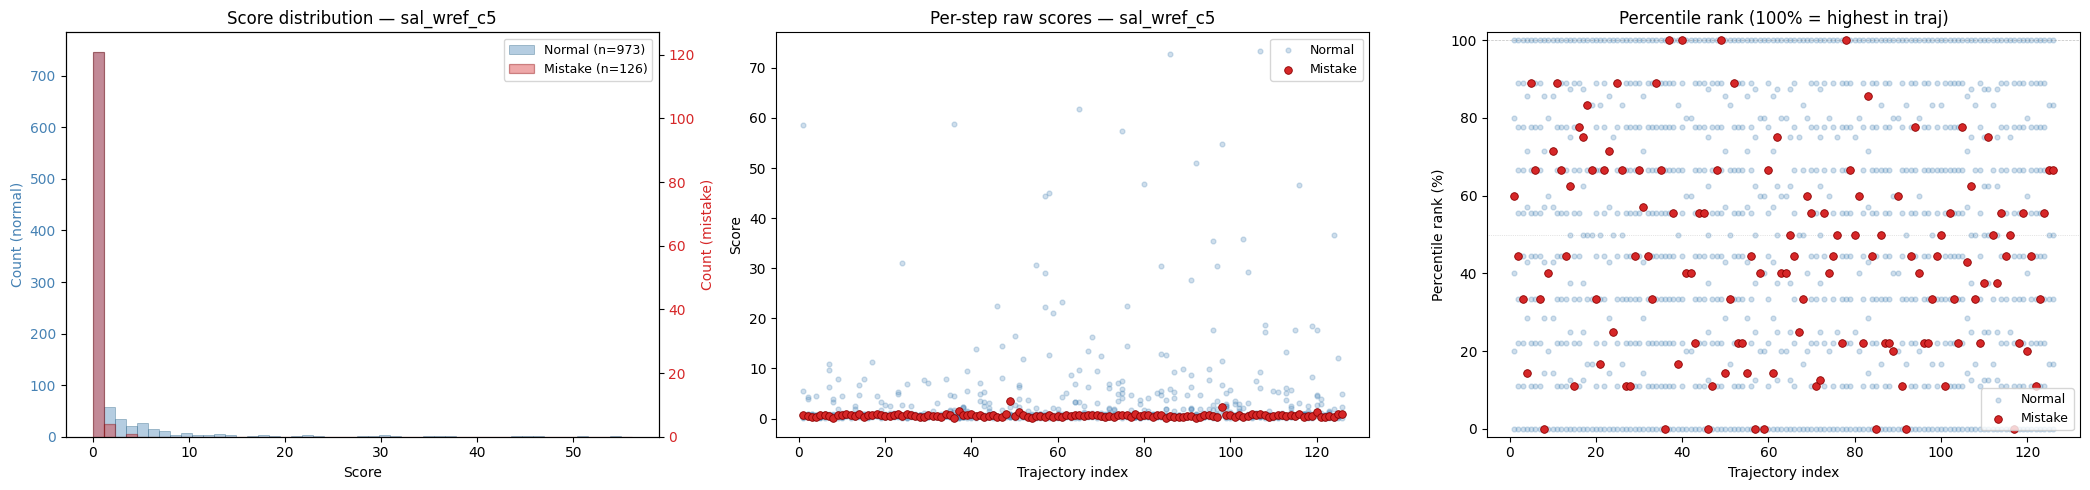

In [65]:
sal_variants = [v for v in score_names if v.startswith("sal_")]
for variant in sal_variants:
    plot_variant(trajectories, variant)

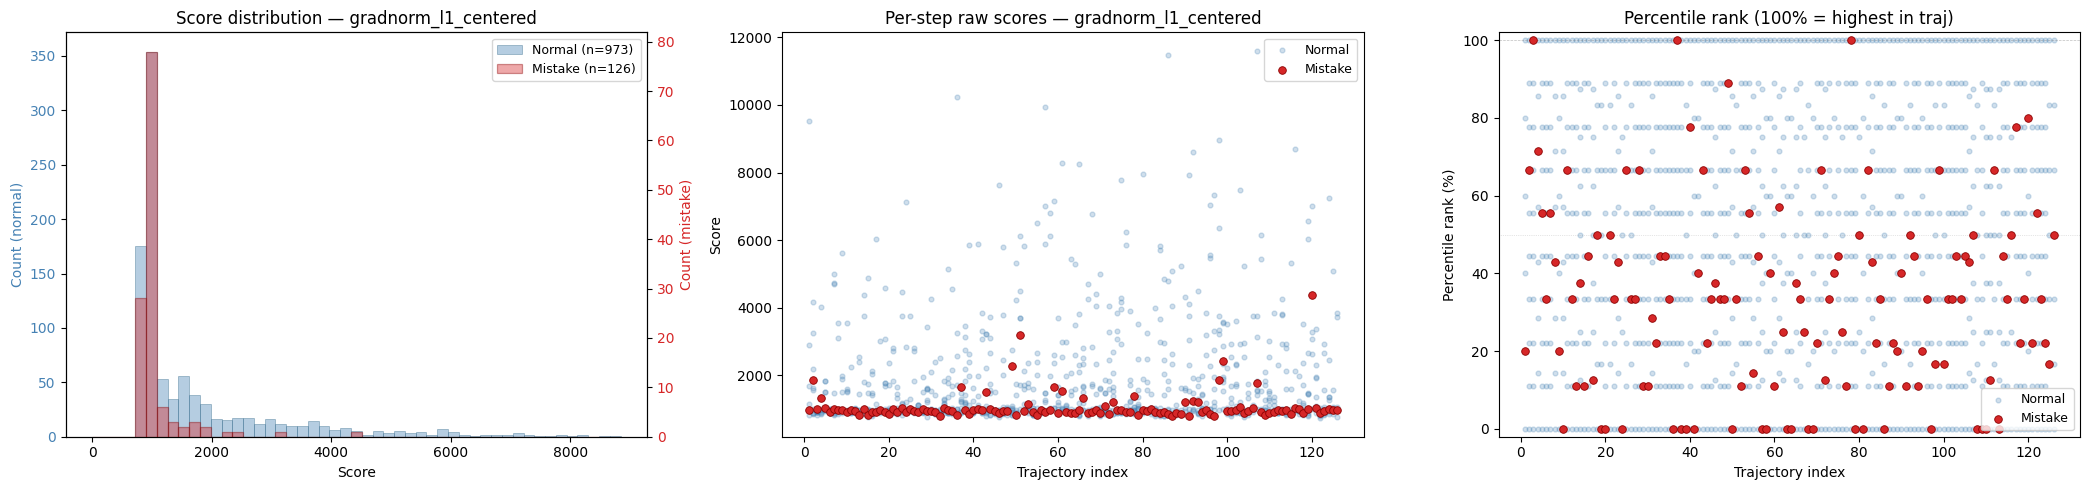

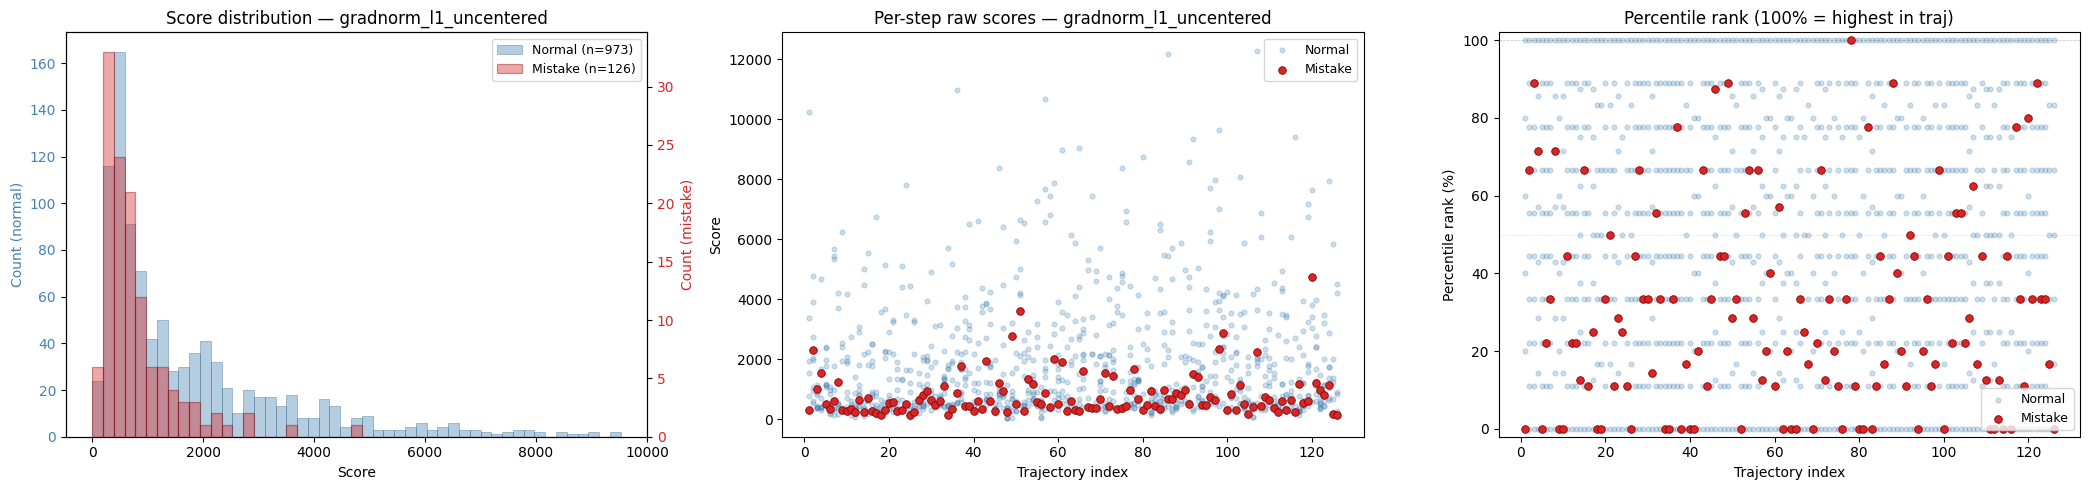

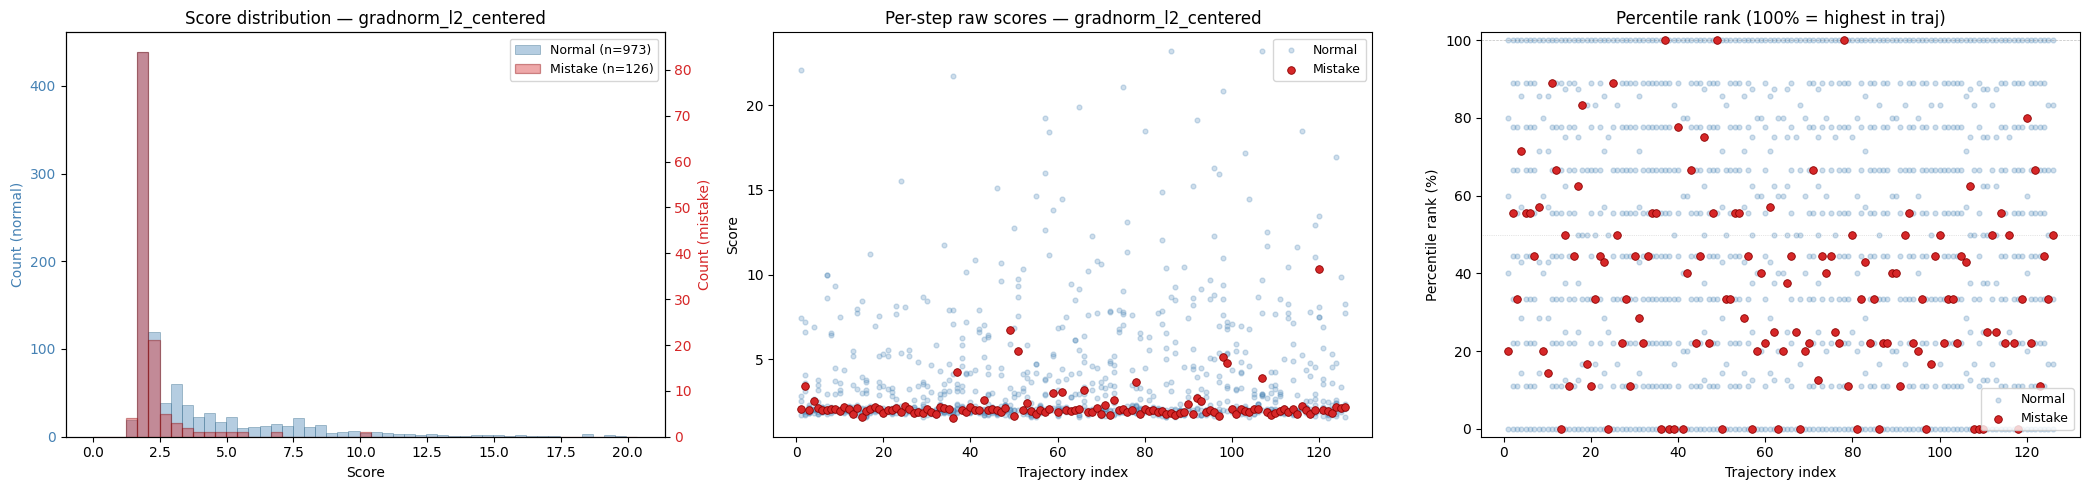

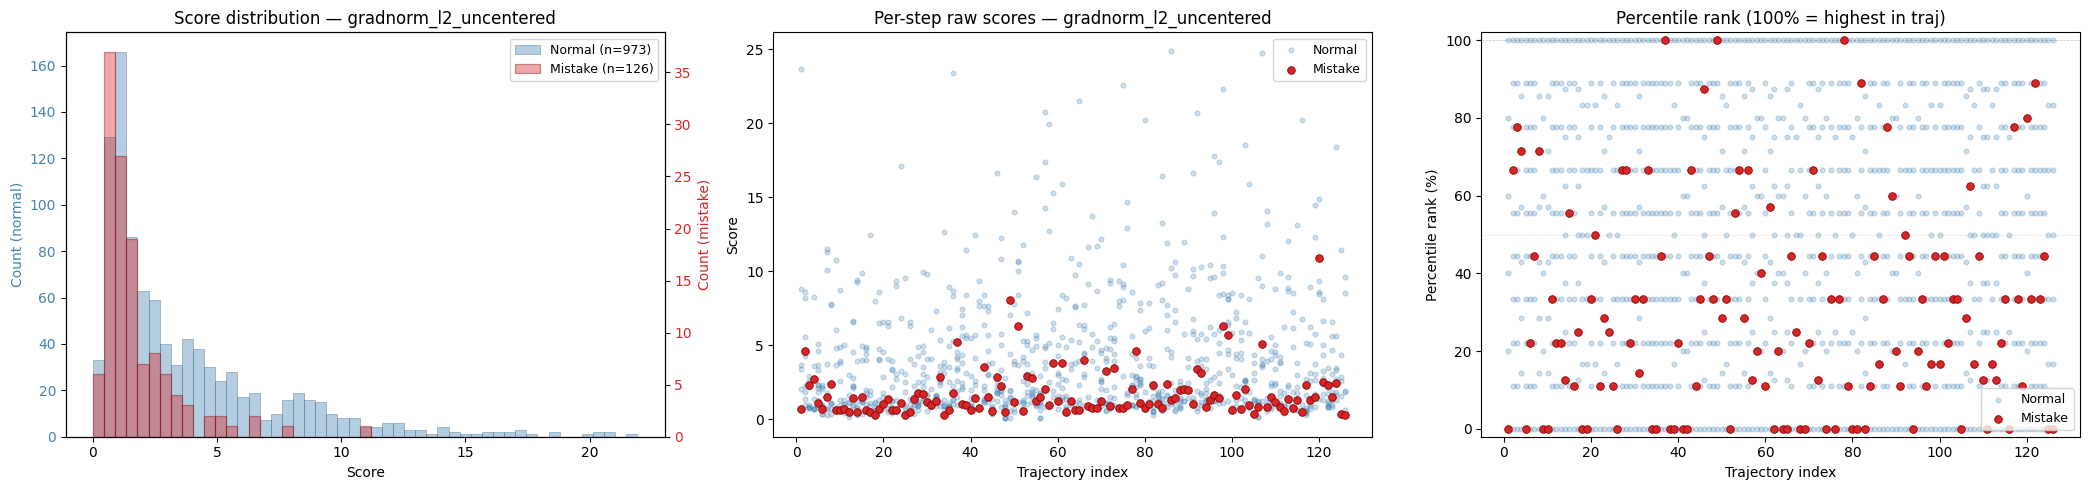

In [66]:
gn_variants = [v for v in score_names if v.startswith("gradnorm_")]
for variant in gn_variants:
    plot_variant(trajectories, variant)

Best SAL variant:      sal_noref_c1  (step_acc desc=0.0238, asc=0.2540)
Best GradNorm variant: gradnorm_l2_uncentered  (step_acc desc=0.0238, asc=0.2381)


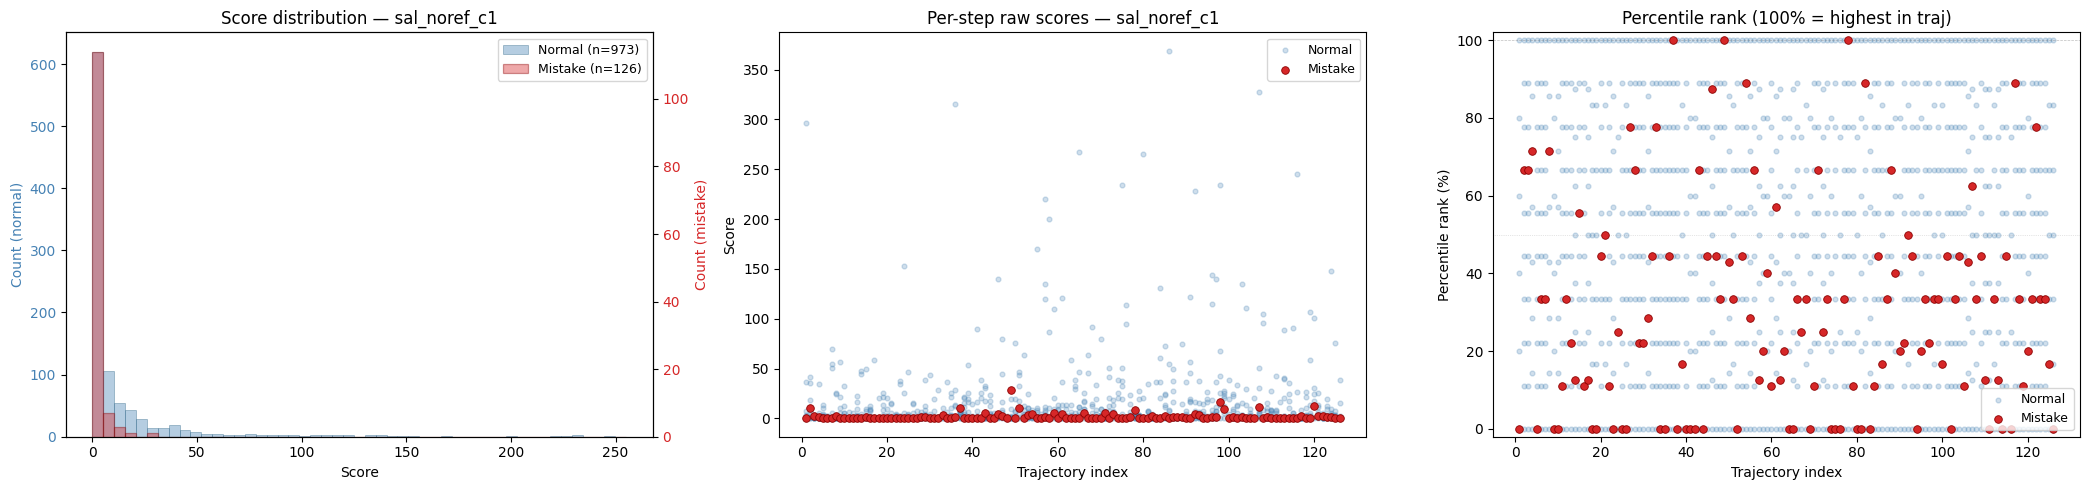

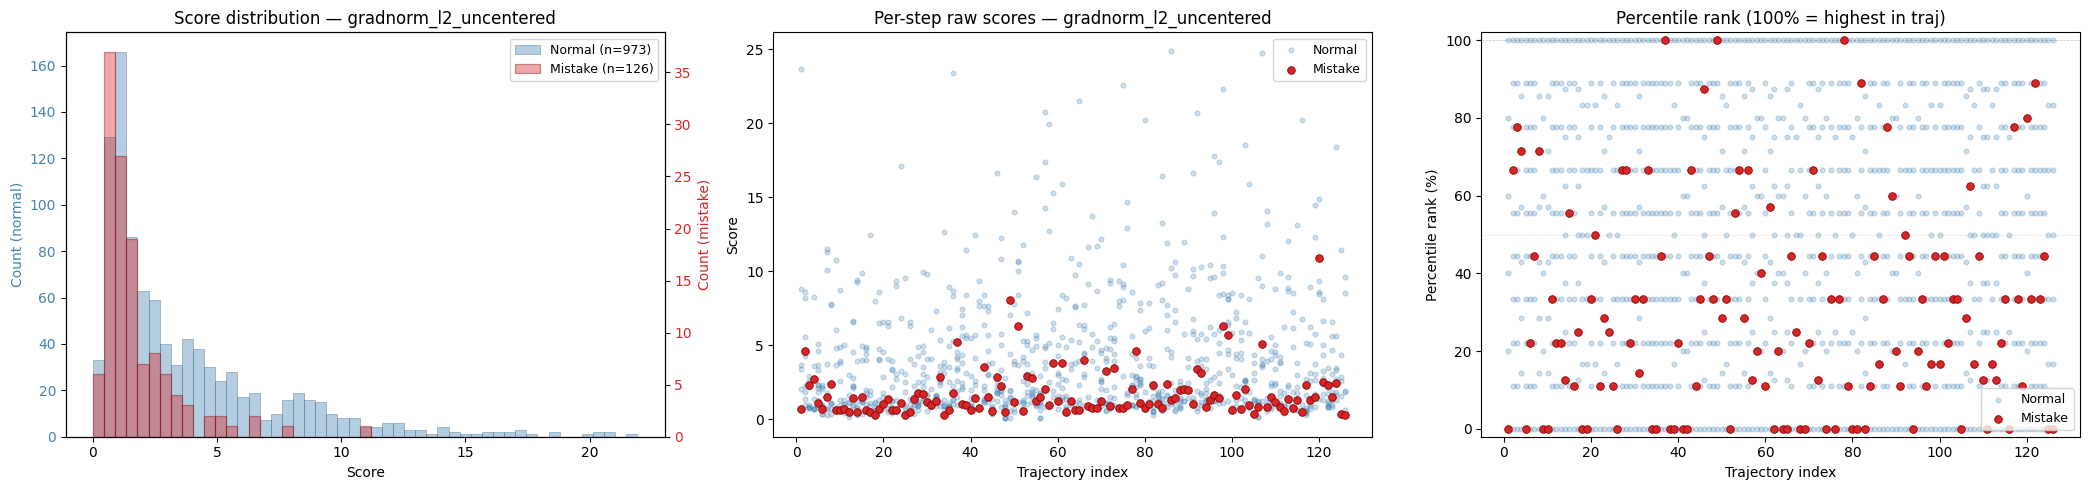

In [67]:
def find_best_variant(eval_results: dict, prefix: str, metric: str = "desc_step_acc") -> str:
    """Find the variant with the highest metric value matching the prefix."""
    candidates = {k: v for k, v in eval_results.items() if k.startswith(prefix)}
    # Check both asc and desc, pick whichever direction is better
    best_name = None
    best_val = -1
    for name, r in candidates.items():
        for direction in ["desc_step_acc", "asc_step_acc"]:
            if r[direction] > best_val:
                best_val = r[direction]
                best_name = name
    return best_name
 
 
best_sal = find_best_variant(eval_results, "sal_")
best_gn  = find_best_variant(eval_results, "gradnorm_")
print(f"Best SAL variant:      {best_sal}  "
      f"(step_acc desc={eval_results[best_sal]['desc_step_acc']:.4f}, "
      f"asc={eval_results[best_sal]['asc_step_acc']:.4f})")
print(f"Best GradNorm variant: {best_gn}  "
      f"(step_acc desc={eval_results[best_gn]['desc_step_acc']:.4f}, "
      f"asc={eval_results[best_gn]['asc_step_acc']:.4f})")
 
for variant in [best_sal, best_gn]:
    plot_variant(trajectories, variant)